# CYNAR paper 1 -- example 4: Lorenz attractor (N=3 baseline)

The classic chaotic Lorenz system with additive noise, $N=3$. Ground truth comes from
`observables_from_trajectory_Lorenz` (known forces along the simulated trajectory); notably the drift's
divergence is *constant* ($-(s+1+b)$), so $\mathcal{G}_{\rm true}=s+1+b$ exactly, with no averaging needed.
This is a low-dimensional bridge case -- still cell-feasible, so a full merit-B (cell-size stability) check
applies -- before `04_lorenz96.ipynb`'s dimension scaling (merit C).

In [9]:
%load_ext autoreload
%autoreload 2

import sys
import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar.simul.Lorenz import simulate_Lorenz, observables_from_trajectory_Lorenz
from cynar.plot import plot_trajectory

import common as C

np.set_printoptions(precision=4, suppress=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Model & simulation

In [10]:
r, s, b = 10.0, 3.0, 1.0
# Block-diagonal: keeps the exotic x-y coupling of the original
# off-diagonal choice, but decouples z's *noise* from (x,y) -- needed
# so sigma splits exactly into an (x,y)-block share plus a z share for
# the partial-observation demo below (D_inv is then block-diagonal too).
# z stays fully coupled to (x,y) through the (unchanged) Lorenz drift, so
# observing only (x,y) is still a genuine partial-observation problem.
D = np.array([[5., -1, 0.], [-1, 5., 0.], [0., 0., 5.]])
D_inv = np.linalg.inv(D)
dt = 1e-3

T = 1_000_000
t, X, divA = simulate_Lorenz(T=T, dt=dt, D=D, x0=1.0, y0=1.0, z0=1.0, r=r, s=s, b=b,
                              scheme="Heun", oversampling=10, seed=12345)

sigma_true, Tr_true, G_true = observables_from_trajectory_Lorenz(X, dt, D_inv, r, s, b)
true_values = dict(Tr_true=Tr_true, G_true=G_true, sigma_true=sigma_true)
print(f"Tr_true={Tr_true:.4f}  G_true={G_true:.4f} (=s+1+b exactly)  sigma_true={sigma_true:.4f}"
      f"  divA_const={divA}")

Tr_true=13.5101  G_true=5.0000 (=s+1+b exactly)  sigma_true=58.8886  divA_const=-5.0


In [ ]:
for i in range(3):
    print(X[:,i].min(),X[:,i].max(),abs(X[:,i].min()-X[:,i].max()))

### Example trajectory

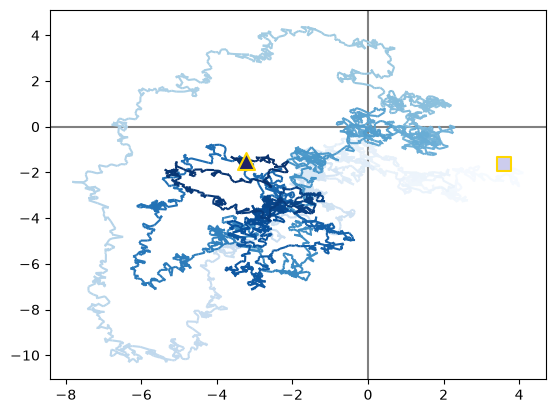

In [12]:
plot_trajectory(X, i=0, j=1, tmin=0, tmax=5000,)

## Merit B: cell-size stability

In [13]:
H_list = np.linspace(0.05, 0.4, 8)
traffic_result = C.sweep_traffic_vs_H(X, dt, H_list, N_slice=5, i1_window=2)
tr_star = C.pick_stable_Tr(traffic_result)
print(f"H* = {tr_star['H_star']:.2f}  Tr* = {tr_star['Tr_star_mean']:.4f} +/- {tr_star['Tr_star_std']:.4f}"
      f"  (true {Tr_true:.4f})")

H* = 0.05  Tr* = 14.3276 +/- 1.3519  (true 13.5101)


### Recovering the full (non-diagonal) diffusion tensor

The off-diagonal $D^{xy}=-1$ chosen above is an "exotic" (non-diagonal) choice, used throughout this
subsection, not just for the partial-observation demo below. Before trusting any downstream result built
on it, check that the traffic fit actually recovers all 6 independent components of $\mathsf D$ -- not
just the 3 diagonal ones -- and that this recovery is itself stable against the fit-window tolerance $H$,
reusing the same per-$H$, per-slice fits already computed above (`traffic_result["D_over_H"]`).

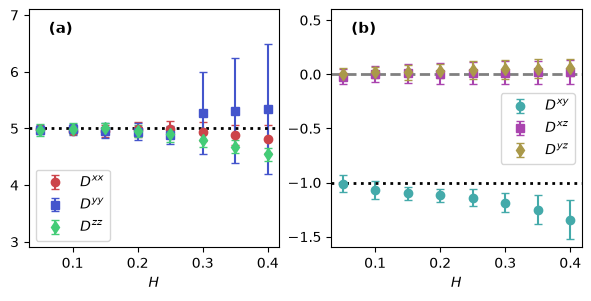

In [14]:
D_stack = np.stack(traffic_result["D_over_H"], axis=0)  # (N_slice, n_H, 3, 3)
Dm = D_stack.mean(axis=0)
Ds = D_stack.std(axis=0, ddof=1)
H_sweep = traffic_result["H_list"]

fig, axs = plt.subplots(1, 2, figsize=(5.8, 2.9), constrained_layout=True)
ms=6
mar_list=["o","s","d"]
diag_idx = [(0, 0), (1, 1), (2, 2)]
diag_labels = [r"$D^{xx}$", r"$D^{yy}$", r"$D^{zz}$"]
diag_colors = ["#CC444A", "#4455CC", "#44CC77"]
for (i, j), lab, col, mar in zip(diag_idx, diag_labels, diag_colors, mar_list):
    axs[0].errorbar(H_sweep, Dm[:, i, j], yerr=Ds[:, i, j], fmt=mar, capsize=3, markersize=ms,
                     color=col, label=lab)
axs[0].axhline(D[0, 0], color="black", linestyle=":", lw=2) #, label=r"true $D^{ii}$")
axs[0].set_xlabel("$H$"); #axs[0].set_ylabel(r"$D^{ii}$")
axs[0].legend(fontsize=10)
C.add_panel_label(axs[0], "(a)")

offdiag_idx = [(0, 1), (0, 2), (1, 2)]
offdiag_labels = [r"$D^{xy}$", r"$D^{xz}$", r"$D^{yz}$"]
offdiag_colors = ["#44AAAA","#AA44AF","#AA994A",]
for (i, j), lab, col, mar in zip(offdiag_idx, offdiag_labels, offdiag_colors, mar_list):
    axs[1].errorbar(H_sweep, Dm[:, i, j], yerr=Ds[:, i, j], fmt=mar, capsize=3, markersize=ms,
                      color=col, label=lab)
axs[1].axhline(D[0, 1], color="black", linestyle=":", lw=2)
axs[1].axhline(D[0, 2], color="gray", linestyle="--", lw=2)
axs[1].set_xlabel("$H$"); #axs[1].set_ylabel(r"$D^{ij},\ i\neq j$")
axs[1].legend(fontsize=10)
C.add_panel_label(axs[1], "(b)")

axs[0].set_ylim(2.9,7.1)
axs[1].set_ylim(-1.6,.6)

fig.savefig(str(C.FIGURES_DIR / "lorenz_D_vs_H.pdf"), dpi=200, bbox_inches="tight")
plt.show()

C.save_result("lorenz_D_vs_H", dict(D_over_H=traffic_result["D_over_H"], H_list=H_sweep, D_true=D))

In [15]:
side0 = np.full(3, 0.5)
R_list = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
cellsize_result = C.sweep_cellsize(X, dt, traffic_result["D_from_traffic"], side0, R_list, traffic_result["slices"])

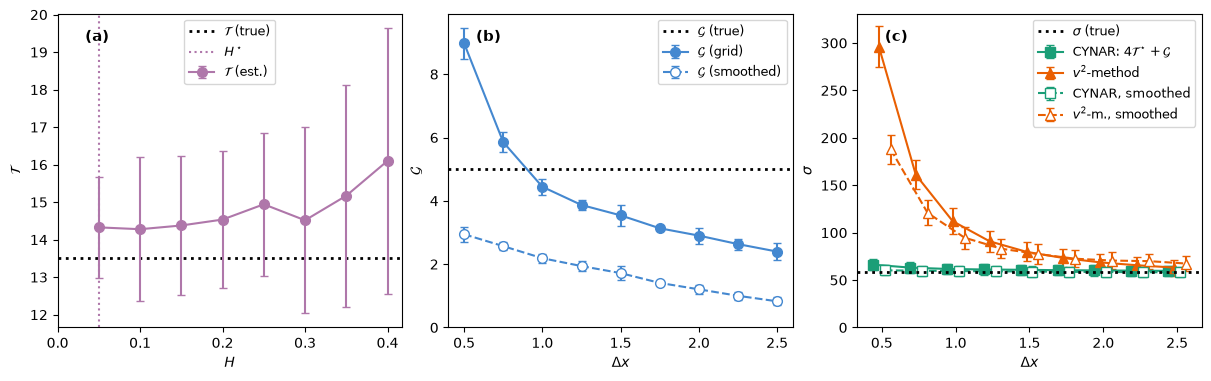

{'Tr_true': 13.51013674056081, 'G_true': 5.0, 'sigma_true': 58.888579895559964}


In [16]:
fig, axs = C.plot_cellsize_stability(traffic_result, tr_star, cellsize_result, true_values,)
axs[0].set_xlim(0,)
axs[1].set_ylim(0,)
axs[2].set_ylim(0,)
fig.savefig(str(C.FIGURES_DIR / "lorenz_cellsize.pdf"), dpi=200, bbox_inches="tight")
plt.show()

C.save_result("lorenz_cellsize", dict(
    traffic_result=traffic_result, tr_star=tr_star, cellsize_result=cellsize_result,
    true_values=true_values, r=r, s=s, b=b, side0=side0,
))

print(true_values)

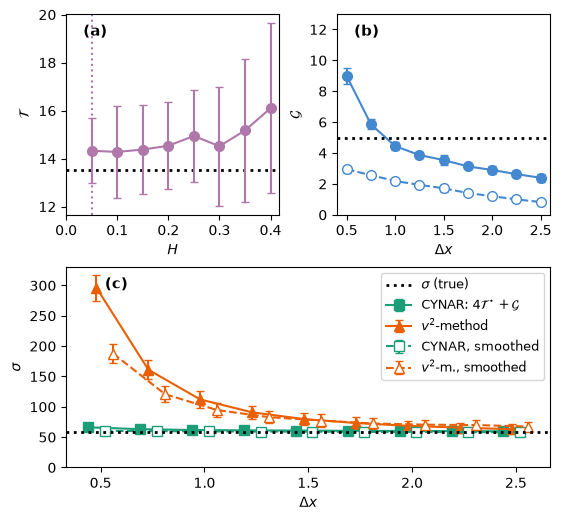

{'Tr_true': 13.51013674056081, 'G_true': 5.0, 'sigma_true': 58.888579895559964}


In [17]:
fig, axs = C.plot_cellsize_stability(traffic_result, tr_star, cellsize_result, true_values,orient="2+1")
axs[0].set_xlim(0,)
axs[1].set_ylim(0,13)
axs[2].set_ylim(0,)
fig.savefig(str(C.FIGURES_DIR / "lorenz_cellsize.pdf"), dpi=200, bbox_inches="tight")
plt.show()

C.save_result("lorenz_cellsize", dict(
    traffic_result=traffic_result, tr_star=tr_star, cellsize_result=cellsize_result,
    true_values=true_values, r=r, s=s, b=b, side0=side0,
))

print(true_values)

## Partial observation

How much of $\sigma$ is recovered from observing only a subset $\Omega$ of the coordinates? Appendix
"Derivation of the improved bound" defines, for any observed subset $\Omega$ with hidden complement $H$,
$\sigma_\Omega\equiv\langle\velo_\Omega\cdot\mathsf D_\Omega^{-1}\velo_\Omega\rangle$ (Eq.~(sigmaS)), the
$v^2$-method's own quadratic form restricted to $\Omega$'s components of the *full* local mean velocity
$\velo$, with $\mathsf D_\Omega$ the $\Omega$-$\Omega$ block of $\mathsf D$. This is well defined and
bounded by $\sigma$ *for any* $\mathsf D$, whether or not it is block-diagonal with respect to $\Omega$
and $H$.

(An earlier version of this notebook instead obtained $\sigma^{xy}$ below from
`sigma_partial_from_trajectory_Lorenz`, an exact, grid-free share built by restricting the Sekimoto/
Stratonovich sum $\sigma=\langle(\mathsf D^{-1}\drift)\circ\dot{\xx}\rangle$'s known-force terms to
$\Omega$'s components. That share is additive over *any* partition by construction, but it equals
$\sigma_\Omega$ only when $\mathsf D$ happens to be block-diagonal with respect to the partition -- as it
is for $\Omega=\{x,y\}$ vs.\ $\{z\}$ below, since $D^{xz}=D^{yz}=0$, which is why it reproduced
$\sigma_{\rm true}$ exactly there. It is formally the *wrong* quantity in general, and gives a different,
generally-incorrect answer once $\Omega$ is no longer aligned with a block of $\mathsf D$ -- exactly the
case for the further subsets tested below, where $D^{xy}=-1$ couples an observed coordinate to a hidden
one. We therefore use $\sigma_\Omega$ throughout, computed as below.)

For each $\Omega$, we compare three things, all at the same representative cell size used above ($R=3$,
i.e.\ $\Delta x=0.75$ in every direction):
- the exact theoretical $\sigma_{\rm true}$ (full system, from `observables_from_trajectory_Lorenz`);
- the **reference** $\sigma_\Omega$ (`v2method.probability_flux_sigma_subsets`), evaluated from the *full*
  3D trajectory and the *full*, known $\mathsf D$, but with $\velo$ restricted to $\Omega$'s components and
  $\mathsf D_\Omega^{-1}$ the inverse of $\Omega$'s own block -- an "oracle" estimate that uses the same
  grid/cell size as the honest estimate below, so that any gap between the two reflects genuine
  information loss from marginalizing over $H$ (Appendix, Eq.~(app:sigmaS-decomp)-(app:GS)), not a
  difference in grid discretization bias;
- the **honest** partial-observation estimate (`common.honest_partial_estimate`), computed with **only**
  $X[:,\Omega]$ and the corresponding block of $\mathsf D$ -- traffic, inflow, and the $v^2$-method all run
  on the marginal trajectory alone, exactly as a real partial observer (no access to $H$) would.

In [18]:
from cynar import v2method
from cynar.cfg import InflowCfg

subset = [0, 1]  # observe x, y; hide z
D_sub = D[np.ix_(subset, subset)]
R_partial = 3.0  # same representative cell size used above (R=3 -> dx=0.75)
side_partial_full = R_partial * side0          # kept for the 2D marginal grid below
side_partial_sub = side_partial_full[subset]    # 2D marginal grid, for the honest estimate

# Reference sigma_Omega for every subset tested in this notebook (xy, z below; x, y, xz,
# yz further down), all from a SINGLE grid pass over the FULL trajectory with the full,
# known D -- see cynar.v2method.probability_flux_sigma_subsets's docstring.
partial_subsets = {"xy": [0, 1], "z": [2], "x": [0], "y": [1], "xz": [0, 2], "yz": [1, 2]}
inflow_cfg_ref = InflowCfg(n_min=2, thr_g=200.0)
sigma_ref = v2method.probability_flux_sigma_subsets(
    X, dt, side_partial_full, D, cfg=inflow_cfg_ref, subsets=partial_subsets)

sigma_xy_ref = sigma_ref["xy"]
sigma_z_ref = sigma_ref["z"]
print("reference sigma_Omega (v2-method, Omega components of the full v, same grid as the honest estimate):")
for key, val in sigma_ref.items():
    print(f"  Omega={key:>2s}: sigma_Omega = {val:8.4f}")
print(f"sigma_xy_ref + sigma_z_ref = {sigma_xy_ref + sigma_z_ref:.4f}"
      f"   (theory sigma_true = {sigma_true:.4f}; equal only up to this grid's own discretization bias,"
      f"   since D is block-diagonal for this particular partition)")

reference sigma_Omega (v2-method, Omega components of the full v, same grid as the honest estimate):
  Omega=xy: sigma_Omega =  34.4739
  Omega= z: sigma_Omega =  28.5727
  Omega= x: sigma_Omega =   8.3495
  Omega= y: sigma_Omega =  22.2119
  Omega=xz: sigma_Omega =  36.9223
  Omega=yz: sigma_Omega =  50.7846
sigma_xy_ref + sigma_z_ref = 63.0466   (theory sigma_true = 58.8886; equal only up to this grid's own discretization bias,   since D is block-diagonal for this particular partition)


In [19]:
# Honest partial-observation estimate: only X[:, subset] and D_sub are ever used below.
honest_xy = C.honest_partial_estimate(X, D, dt, subset, H_list, side0, R_partial, i1_window=2, N_slice=5)
tr_star_sub = honest_xy["tr_star"]
sigma_cynar_sub_mean, sigma_cynar_sub_std = honest_xy["sigma_cynar_mean"], honest_xy["sigma_cynar_std"]
sigma_v2_sub_mean, sigma_v2_sub_std = honest_xy["sigma_v2_mean"], honest_xy["sigma_v2_std"]

print(f"honest partial: H*={tr_star_sub['H_star']:.2f}  Tr*={tr_star_sub['Tr_star_mean']:.4f}"
      f"+/-{tr_star_sub['Tr_star_std']:.4f}")
print(f"honest partial CYNAR: sigma_xy = {sigma_cynar_sub_mean:.4f} +/- {sigma_cynar_sub_std:.4f}"
      f"   (reference sigma_xy = {sigma_xy_ref:.4f}, theory sigma_true {sigma_true:.4f})")
print(f"honest partial v2:    sigma_xy = {sigma_v2_sub_mean:.4f} +/- {sigma_v2_sub_std:.4f}"
      f"   (reference sigma_xy = {sigma_xy_ref:.4f}, theory sigma_true {sigma_true:.4f})")

C.save_result("lorenz_partial_observation", dict(
    subset=subset, D=D, D_sub=D_sub, side_partial_full=side_partial_full,
    sigma_xy_ref=sigma_xy_ref, sigma_z_ref=sigma_z_ref, sigma_true=sigma_true,
    tr_star_sub=tr_star_sub, honest_xy=honest_xy,
    sigma_cynar_sub_mean=sigma_cynar_sub_mean, sigma_cynar_sub_std=sigma_cynar_sub_std,
    sigma_v2_sub_mean=sigma_v2_sub_mean, sigma_v2_sub_std=sigma_v2_sub_std,
))

honest partial: H*=0.05  Tr*=7.3912+/-0.9128
honest partial CYNAR: sigma_xy = 32.0198 +/- 3.6527   (reference sigma_xy = 34.4739, theory sigma_true 58.8886)
honest partial v2:    sigma_xy = 20.2817 +/- 2.8519   (reference sigma_xy = 34.4739, theory sigma_true 58.8886)


## Partial observation: a single coordinate ($z$ alone)

A further, more extreme test: observe only $z$, a single scalar coordinate, decoupled in *noise* from
$(x,y)$ by the same $\mathsf D$ used above ($D^{xz}=D^{yz}=0$, so $\Omega=\{z\}$ is aligned with a block
of $\mathsf D$, like $\Omega=\{x,y\}$ above). This is the case where a general structural argument applies:
for a single observed coordinate with natural (non-periodic, density-decaying) boundary conditions, the
steady-state probability current of its own marginal distribution is *identically zero* -- the
$v^2$-method, which estimates exactly that current, should therefore collapse to (numerically) zero
regardless of the true dissipation, while CYNAR's traffic-based estimate, needing only $z$'s own
autocorrelation function, is under no such constraint. No code changes were needed to test this: `compute_traffic`,
`grid_inflow`, and `v2method.grid_v2` all accept 1D trajectory arrays (`X.shape=(T,1)`) and 1x1 diffusion
"matrices" without modification.

In [23]:
subset_z = [2]
D_z = D[np.ix_(subset_z, subset_z)]
side_partial_z = side_partial_full[subset_z]

print(f"reference sigma_z = {sigma_z_ref:.4f}   (theory sigma_true = {sigma_true:.4f})")

honest_z = C.honest_partial_estimate(X, D, dt, subset_z, H_list, side0, R_partial, i1_window=2, N_slice=5)
tr_star_z = honest_z["tr_star"]
sigma_cynar_z_mean, sigma_cynar_z_std = honest_z["sigma_cynar_mean"], honest_z["sigma_cynar_std"]
sigma_v2_z_mean, sigma_v2_z_std = honest_z["sigma_v2_mean"], honest_z["sigma_v2_std"]

print(f"honest partial (z): H*={tr_star_z['H_star']:.2f}  Tr*={tr_star_z['Tr_star_mean']:.4f}"
      f"+/-{tr_star_z['Tr_star_std']:.4f}")
print(f"honest partial CYNAR (z only): sigma_z = {sigma_cynar_z_mean:.4f} +/- {sigma_cynar_z_std:.4f}"
      f"   (reference sigma_z = {sigma_z_ref:.4f})")
print(f"honest partial v2 (z only):    sigma_z = {sigma_v2_z_mean:.6f} +/- {sigma_v2_z_std:.6f}"
      f"   -- expected to collapse to ~0 (single-coordinate marginal current vanishes identically)")

C.save_result("lorenz_partial_observation_z", dict(
    subset=subset_z, D_z=D_z, side_partial_z=side_partial_z,
    sigma_z_ref=sigma_z_ref, sigma_true=sigma_true,
    tr_star_z=tr_star_z, honest_z=honest_z,
    sigma_cynar_z_mean=sigma_cynar_z_mean, sigma_cynar_z_std=sigma_cynar_z_std,
    sigma_v2_z_mean=sigma_v2_z_mean, sigma_v2_z_std=sigma_v2_z_std,
))

reference sigma_z = 28.5727   (theory sigma_true = 58.8886)
honest partial (z): H*=0.10  Tr*=6.7339+/-0.7864
honest partial CYNAR (z only): sigma_z = 27.4380 +/- 3.1466   (reference sigma_z = 28.5727)
honest partial v2 (z only):    sigma_z = 0.002478 +/- 0.001280   -- expected to collapse to ~0 (single-coordinate marginal current vanishes identically)


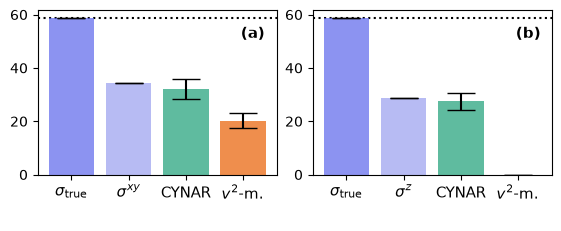

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.2), constrained_layout=True)

C.plot_partial_observation_bar_panel(axs[0], sigma_true, sigma_xy_ref, sigma_cynar_sub_mean, sigma_cynar_sub_std,
                                      sigma_v2_sub_mean, sigma_v2_sub_std, subset_label="xy",
                                      panel_label="(a)", panel_label_kw=dict(pad_x=0.85, pad_y=0.1))
C.plot_partial_observation_bar_panel(axs[1], sigma_true, sigma_z_ref, sigma_cynar_z_mean, sigma_cynar_z_std,
                                      sigma_v2_z_mean, sigma_v2_z_std, subset_label="z",
                                      panel_label="(b)", panel_label_kw=dict(pad_x=0.85, pad_y=0.1))

fig.savefig(str(C.FIGURES_DIR / "lorenz_partial_observation.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Partial observation: subsets coupled to the hidden part through the noise

The $\{x,y\}$/$\{z\}$ split above is a favorable case: $D^{xz}=D^{yz}=0$, so the noise itself never
couples an observed coordinate to a hidden one, whichever of the two subsets is observed. We now test the
opposite situation, where $D^{xy}=-1\neq0$ ties an observed coordinate to a *hidden* one: $\Omega=\{x\}$
alone (hiding $y,z$), $\Omega=\{y\}$ alone (hiding $x,z$), $\Omega=\{x,z\}$ (hiding $y$), and
$\Omega=\{y,z\}$ (hiding $x$). In each of these four, $\mathsf D_\Omega$ is itself diagonal ($D^{xz}=D^{yz}=0$),
but $\Omega$ is *not* a block of the full $\mathsf D$ -- exactly the regime where the old grid-free
Sekimoto-mask share would have given the wrong quantity, and where using the properly-defined
$\sigma_\Omega=\langle\velo_\Omega\cdot\mathsf D_\Omega^{-1}\velo_\Omega\rangle$ (as reference and as the
honest estimate's target) matters.

In [27]:
extra_subsets = {"x": [0], "y": [1], "xz": [0, 2], "yz": [1, 2]}
honest_extra = {}
for key, sub in extra_subsets.items():
    honest_extra[key] = C.honest_partial_estimate(X, D, dt, sub, H_list, side0, R_partial,
                                                    i1_window=2, N_slice=5)
    h = honest_extra[key]
    print(f"Omega={key:>2s}: reference sigma_Omega={sigma_ref[key]:8.4f}   "
          f"honest CYNAR={h['sigma_cynar_mean']:8.4f}+/-{h['sigma_cynar_std']:.4f}   "
          f"honest v2={h['sigma_v2_mean']:8.4f}+/-{h['sigma_v2_std']:.4f}")

C.save_result("lorenz_partial_observation_extra", dict(
    extra_subsets=extra_subsets, D=D, side_partial_full=side_partial_full,
    sigma_ref=sigma_ref, sigma_true=sigma_true, honest_extra=honest_extra,
))

Omega= x: reference sigma_Omega=  8.3495   honest CYNAR=  5.4232+/-0.4330   honest v2=  0.0034+/-0.0020
Omega= y: reference sigma_Omega= 22.2119   honest CYNAR= 20.6483+/-2.2860   honest v2=  0.0023+/-0.0011
Omega=xz: reference sigma_Omega= 36.9223   honest CYNAR= 33.3587+/-3.7121   honest v2= 18.7156+/-3.1075
Omega=yz: reference sigma_Omega= 50.7846   honest CYNAR= 48.1168+/-5.3528   honest v2= 36.1581+/-3.8799


## Combined figure: six observed subsets

Three rows, two columns: row 1 reproduces the $\{x,y\}$/$\{z\}$ pair above (Fig.~9, unchanged); row 2 is
the two single coordinates $x$ and $y$ alone; row 3 is the two coordinate pairs $\{x,z\}$ and $\{y,z\}$.
Rows 2-3 are the subsets where the noise couples $\Omega$ to $H$.

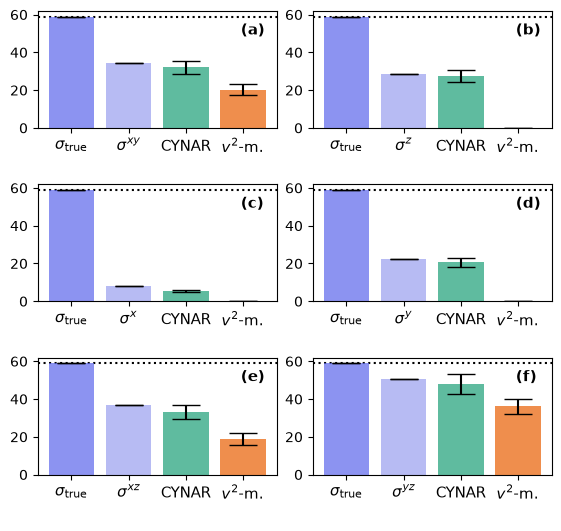

In [31]:
fig, axs = plt.subplots(3, 2, figsize=(5.5, 5.2), constrained_layout=True)

row_panels = [
    ("(a)", "xy", sigma_cynar_sub_mean, sigma_cynar_sub_std, sigma_v2_sub_mean, sigma_v2_sub_std),
    ("(b)", "z",  sigma_cynar_z_mean,   sigma_cynar_z_std,   sigma_v2_z_mean,   sigma_v2_z_std),
    ("(c)", "x",  honest_extra["x"]["sigma_cynar_mean"],  honest_extra["x"]["sigma_cynar_std"],
                  honest_extra["x"]["sigma_v2_mean"],     honest_extra["x"]["sigma_v2_std"]),
    ("(d)", "y",  honest_extra["y"]["sigma_cynar_mean"],  honest_extra["y"]["sigma_cynar_std"],
                  honest_extra["y"]["sigma_v2_mean"],     honest_extra["y"]["sigma_v2_std"]),
    ("(e)", "xz", honest_extra["xz"]["sigma_cynar_mean"], honest_extra["xz"]["sigma_cynar_std"],
                  honest_extra["xz"]["sigma_v2_mean"],    honest_extra["xz"]["sigma_v2_std"]),
    ("(f)", "yz", honest_extra["yz"]["sigma_cynar_mean"], honest_extra["yz"]["sigma_cynar_std"],
                  honest_extra["yz"]["sigma_v2_mean"],    honest_extra["yz"]["sigma_v2_std"]),
]

for ax, (label, key, cynar_mean, cynar_std, v2_mean, v2_std) in zip(axs.flat, row_panels):
    C.plot_partial_observation_bar_panel(ax, sigma_true, sigma_ref[key], cynar_mean, cynar_std,
                                          v2_mean, v2_std, subset_label=key,
                                          panel_label=label, panel_label_kw=dict(pad_x=0.85, pad_y=0.1))

fig.savefig(str(C.FIGURES_DIR / "lorenz_partial_observation_extended.pdf"), dpi=200, bbox_inches="tight")
plt.show()